# Superstore Sales Workflow Tutorial

This notebook walks through cleaning the Superstore dataset, designing a relational structure, creating an SQLite database, and running example SQL queries and visualizations.

In [3]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

## 1️) Load and Inspect the Dataset

In [4]:
# reading error codes + research is how you can learn if there is different encoding, as seen below
df = pd.read_csv('../data/Superstore.csv', encoding='ISO-8859-1')
df.head()
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

### Double check some datatypes, and for nulls and duplicates:

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

This data is incredibly clean - we can see there are no null values and no duplicates. However, there are some dates that could be saved in a better format.

## 2) Data Cleaning

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [9]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [10]:
df.Segment.unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [11]:
df.rename(columns={"Segment":"customer_category"}, inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,customer_category,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


With real data, it is very likely more cleaning and wrangling would be required. 

## 3) Build Relational Tables

In [12]:
conn = sqlite3.connect('../data/superstore.db')

customers_df = df[['Customer ID','Customer Name','customer_category','City','State','Region', 'Postal Code']].drop_duplicates().rename(columns={
    'Customer ID':'customer_id',
    'Customer Name':'customer_name',
    'City':'city',
    'State':'state',
    'Region':'region',
    'Postal Code': 'zipcode'
})

products_df = df[['Product ID','Category','Sub-Category','Product Name']].drop_duplicates().rename(columns={
    'Product ID':'product_id',
    'Category':'category',
    'Sub-Category':'subcategory',
    'Product Name':'product_name'
})

orders_df = df[['Order ID','Order Date','Ship Date','Ship Mode','Customer ID']].drop_duplicates().rename(columns={
    'Order ID':'order_id',
    'Order Date':'order_date',
    'Ship Date':'ship_date',
    'Ship Mode':'ship_mode',
    'Customer ID':'customer_id'
})

order_details_df = df[['Order ID','Product ID','Sales','Quantity','Discount','Profit']].rename(columns={
    'Order ID':'order_id',
    'Product ID':'product_id'
})


customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_details_df.to_sql('order_details', conn, index=False, if_exists='replace')
conn.commit()

In [13]:
for name, df in [
    ('customers', customers_df),
    ("products", products_df),
    ("orders", orders_df),
    ("order_details", order_details_df)
]:
    df.to_csv(f'../data/{name}.csv')

## 4) Make Some Queries!

### Which customer segments bring in the most revenue and profit?

In [14]:
query1 = """ SELECT 
    c.customer_category,
    ROUND(SUM(od.sales), 2) AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY total_sales DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

,customer_category,total_sales,total_profit
0,Consumer,8380282.43,973085.86
1,Corporate,5044899.83,660287.69
2,Home Office,2964459.36,434344.01


### What are the top 10 customers by total sales?

In [15]:
query2 = """ select
c.customer_name, sum(od.sales) as total_sales
from orders as o
join order_details as od on od.order_id = o.order_id
join customers as c on c. customer_id = o.customer_id
group by c.customer_name
order by total_sales desc
limit 10
    
 """
result2 = pd.read_sql(query2, conn)
result2

,customer_name,total_sales
0,Ken Lonsdale,155927.519
1,Sanjit Engle,134303.818
2,Clay Ludtke,130566.552
3,Adrian Barton,130262.139
4,Sanjit Chand,127281.006
5,Sean Miller,125215.250
6,Edward Hooks,123730.560
7,Greg Tran,118201.200
8,Seth Vernon,114709.500
9,John Lee,107799.153


### Which product categories and subcategories are the most profitable overall?

In [71]:
query3 = """ Select 
p.category, p.subcategory, max(od.profit) as most_profitable
from products as p
join order_details as od on od.product_id = p.product_id
group by p.category

"""
result3 = pd.read_sql(query3, conn)
result3

,category,subcategory,most_profitable
0,Furniture,Bookcases,1013.127
1,Office Supplies,Binders,4946.370
2,Technology,Copiers,8399.976


### What is the average discount given per category?

In [17]:
query4 = """ Select avg(od.discount) as average_discount, 
p.category
from order_details as od
join products as p on p.product_id = od.product_id
group by category
"""
result4 = pd.read_sql(query4, conn)
result4

,average_discount,category
0,0.172514,Furniture
1,0.157000,Office Supplies
2,0.132970,Technology


### Which states or regions contribute the most to total sales?

In [18]:
query5 = """Select c.region, c.state, 
sum(od.sales) as total_sales,
o.order_id
from customers as c
join orders as o on o.customer_id = c.customer_id
join order_details as od on od.order_id = o.order_id
group by c.region
order by total_sales desc

"""
result5 = pd.read_sql(query5, conn)
result5

,region,state,total_sales,order_id
0,West,California,5.306522e+06,CA-2013-106656
1,East,Pennsylvania,4.522990e+06,CA-2011-113383
2,Central,Texas,3.853692e+06,CA-2011-121664
3,South,Kentucky,2.706438e+06,CA-2013-152156


### How many orders were shipped late (where Ship Date > Order Date + 3 days)?

In [19]:
query6 = """select count(order_id) as late_orders, order_date, ship_date
from orders
where ship_date > order_date + 3
group by ship_date
 """
result6 = pd.read_sql(query6, conn)
result6

,late_orders,order_date,ship_date
0,2,2011-01-07 00:00:00,2011-01-08 00:00:00
1,2,2011-01-05 00:00:00,2011-01-09 00:00:00
2,1,2011-01-07 00:00:00,2011-01-11 00:00:00
3,2,2011-01-06 00:00:00,2011-01-13 00:00:00
4,1,2011-01-10 00:00:00,2011-01-14 00:00:00
...,...,...,...
1329,7,2014-12-29 00:00:00,2015-01-02 00:00:00
1330,5,2014-12-29 00:00:00,2015-01-03 00:00:00
1331,4,2014-12-31 00:00:00,2015-01-04 00:00:00
1332,2,2014-12-29 00:00:00,2015-01-05 00:00:00


### Which month or year had the highest total sales?

In [20]:
query7 = """select strftime('%Y', o.order_date) as year, 
sum(od.sales) as total_sales
from order_details as od
join orders as o on o.order_id = od.order_id
group by year
order by year, total_sales desc
limit 10

"""
result7 = pd.read_sql(query7, conn)
result7

,year,total_sales
0,2011,484247.4981
1,2012,470532.5090
2,2013,608473.8300
3,2014,733947.0232


### What are the most frequently ordered products?

In [29]:
query8 = """select count(*) as frequently_ordered, p.product_name
from products as p
join order_details as od on od.product_id = p.product_id
group by p.product_name
order by frequently_ordered desc
limit 20
 """
result8 = pd.read_sql(query8, conn)
result8

,frequently_ordered,product_name
0,227,Staples
1,20,Avery Non-Stick Binders
2,19,Xerox 1908
3,19,Xerox 1881
4,18,Logitech P710e Mobile Speakerphone
5,18,KI Adjustable-Height Table
6,18,Imation 16GB Mini TravelDrive USB 2.0 Flash Drive
7,17,Storex Dura Pro Binders
8,16,"Executive Impressions 13"" Clairmont Wall Clock"
9,16,"Eldon Image Series Desk Accessories, Burgundy"


### Which customers placed more than 5 orders total?

In [22]:
query9 = """select count(c.customer_id) as total_orders, c.customer_name
from customers as c
join orders as o on o.customer_id = c.customer_id
join order_details as od on od.order_id = o.order_id
group by c.customer_name
having count(c.customer_id) > 5
order by total_orders

"""
result9 = pd.read_sql(query9, conn)
result9

,total_orders,customer_name
0,6,Adrian Shami
1,6,Brad Thomas
2,6,Gene Hale
3,6,Greg Hansen
4,6,Hilary Holden
...,...,...
771,377,Sally Hughsby
772,384,Edward Hooks
773,403,Zuschuss Carroll
774,407,William Brown


### What’s the profit margin (profit ÷ sales) by category or segment?

In [23]:
query10 = """select p.category, p.product_id,
(od.profit / od.sales) as profit_margin
from order_details as od
join products as p on p.product_id = od.product_id
group by p.category
"""
result10 = pd.read_sql(query10, conn)
result10

,category,product_id,profit_margin
0,Furniture,FUR-BO-10001798,0.16
1,Office Supplies,OFF-LA-10000240,0.47
2,Technology,TEC-PH-10002275,0.10


### 5) Visualize it!

From your ten results, select at least 4 to utilize in a meaningful visualization. 

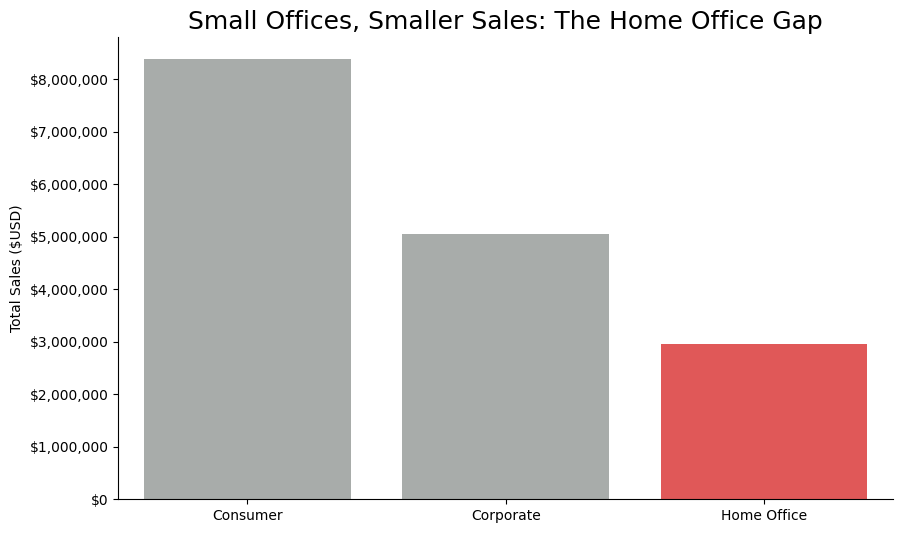

In [24]:
# example using result1
plt.figure(figsize=(10,6))
colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()


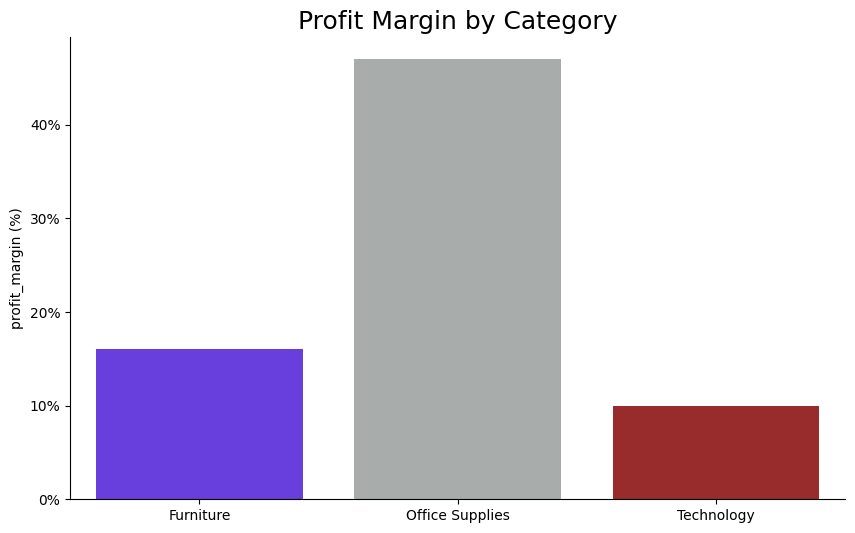

In [25]:
# visualization one code here
plt.figure(figsize=(10,6))
colors = ["#5b23f7", "#a7adaa", "#aa1a1a" ]
sns.barplot(result10, 
            x='category', 
            y='profit_margin', 
            palette=colors,  hue='category', legend=False)
plt.title('Profit Margin by Category',fontsize=18)
plt.xlabel(None)
plt.ylabel('profit_margin (%)')

plt.ticklabel_format(style='plain', axis='y')


ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0%}'))

sns.despine()
plt.show()


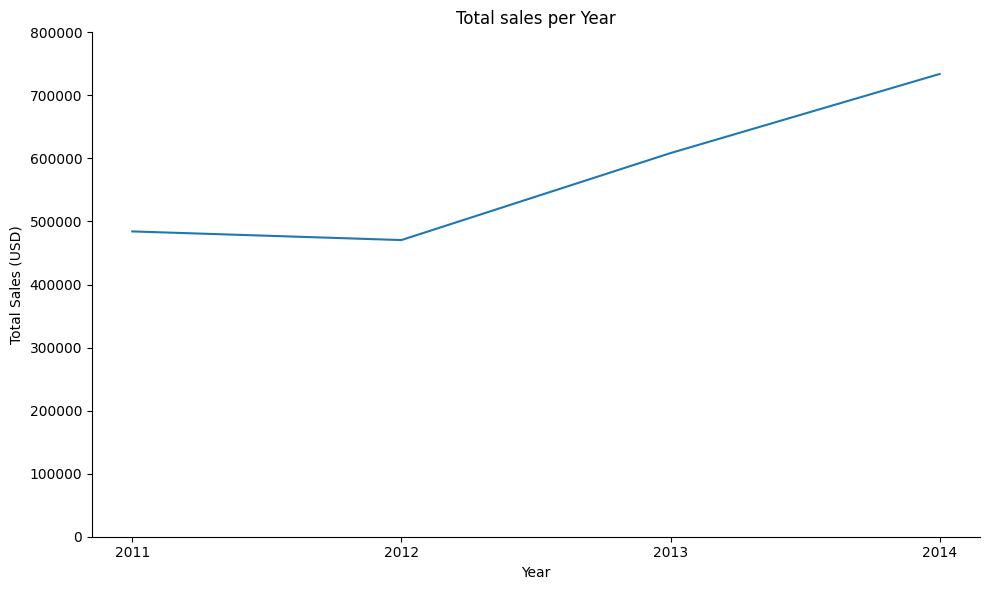

In [63]:
# visualization two code here


plt.figure(figsize=(10,6))
plt.plot(result7['year'], result7['total_sales'])
plt.title('Total sales per Year')

plt.xlabel('Year')
plt.ylabel('Total Sales (USD)')
plt.ylim(0,800000)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



plt.tight_layout()
plt.show()


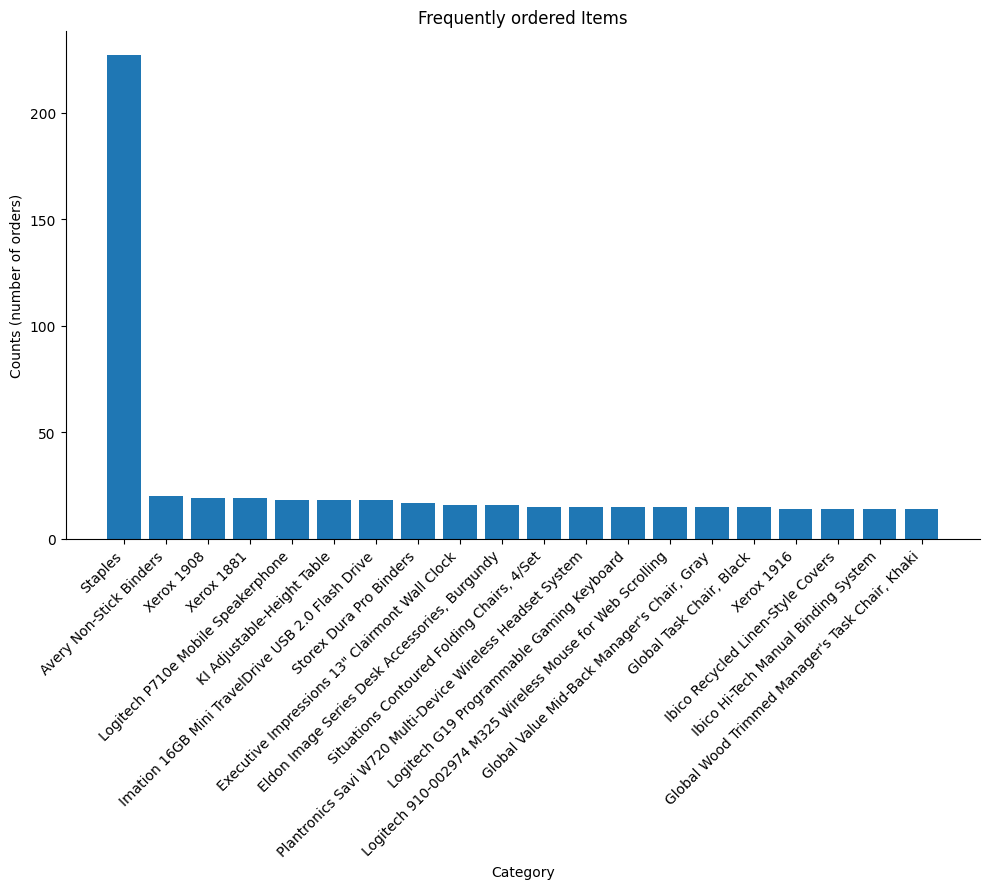

In [48]:
# visualization three code here




plt.figure(figsize=(10,9))

plt.bar(result8['product_name'], result8['frequently_ordered'])

plt.xlabel("Category")
plt.ylabel("Counts (number of orders)")
plt.title("Frequently ordered Items")
plt.xticks(rotation = 45, ha = "right")


ax =plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.show()

In [ ]:
query3 = """ Select 
p.category, p.subcategory, max(od.profit) as most_profitiable
from products as p
join order_details as od on od.product_id = p.product_id
group by category

"""
result3 = pd.read_sql(query3, conn)
result3

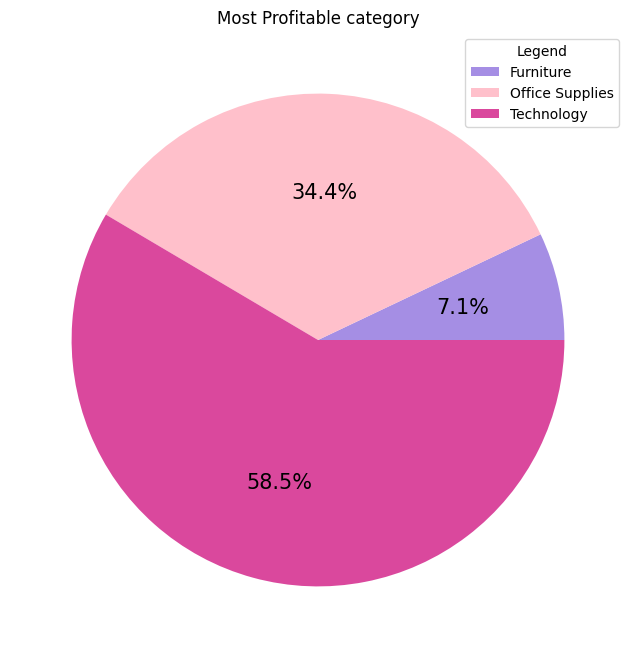

In [91]:
# visualization four code here
plt.figure(figsize = (8,8))
plt.pie(result3['most_profitable'],
        labels=None,
        colors = ["#a58ee4", "pink", "#da489d"],
        autopct = "%1.1f%%",
        textprops={"fontsize": 15})

plt.title("Most Profitable category")

plt.legend(
    result3['category'],
    title= "Legend"
    )
    



plt.show()
